# Multiple Q-learning on Dynamic Treatement Regimes : a cancer simulation case study

In [3]:
# ----------------------------------------------------------
# Librairies
# ----------------------------------------------------------

import numpy as np
import pandas as pd
import sys, time, random
import matplotlib.pyplot as plt
import os
import time
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------
# Repro
# ----------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------------------------------------
# Imports
# ----------------------------------------------------------
sys.path.append("scripts")

import DTR_Cancer_DataGeneration as gen
from DTR_Cancer_DataGeneration import (
    generate_dataset,
    calculate_rewards,
    create_data_stage_frames,
    constant_dose_regimes,
    generate_patient_trajectory
)

from NearEquivalentQlearning import NearEquivalentQlearning, classicalQlearning

In [4]:
# ----------------------------------------------------------
# Config 
# ----------------------------------------------------------
N_train = 500
N_traj  = 5000

T_final = 6
number_of_decision = 5  # stages 0..5

possibles_treatments = np.round(np.arange(0.1, 1.1, 0.1), 1)

# ----------------------------------------------------------
# Helpers
# ----------------------------------------------------------
def stagewise_standardize_numeric_only(data_stages_raw: dict, max_stage: int):
    data_stages_scaled = {}
    stage_scalers = {}
    for k in range(max_stage + 1):
        key = f"Data_Stage_{k}"
        Xk = data_stages_raw[key].copy()
        num_cols = Xk.select_dtypes(include=[np.number]).columns.tolist()
        scaler = StandardScaler()
        Xk[num_cols] = scaler.fit_transform(Xk[num_cols])
        data_stages_scaled[key] = Xk
        stage_scalers[k] = scaler
    return data_stages_scaled, stage_scalers

def get_stage_model(models_by_stage, stage: int, policy_index: int):
    """
    Stage 0..4 : list[SVR]
    Stage 5    : single SVR
    """
    m = models_by_stage[stage]
    if isinstance(m, list):
        idx = min(policy_index, len(m) - 1)
        return m[idx]
    return m

def build_policy_Qs_from_models(models_by_stage, policy_index: int):
    return (
        get_stage_model(models_by_stage, 0, policy_index),
        get_stage_model(models_by_stage, 1, policy_index),
        get_stage_model(models_by_stage, 2, policy_index),
        get_stage_model(models_by_stage, 3, policy_index),
        get_stage_model(models_by_stage, 4, policy_index),
        get_stage_model(models_by_stage, 5, policy_index),
    )

In [5]:
# ----------------------------------------------------------
# Data + rewards
# ----------------------------------------------------------
t_block = time.perf_counter()

Data_raw, Remission_Informations, Dead_Informations = generate_dataset(N=N_train)

Rewards_Zhao = calculate_rewards(
    Data_raw,
    Remission_Informations,
    Dead_Informations,
    T_final=T_final
)

for k in range(number_of_decision + 1):
    assert f"Reward_{k}" in Rewards_Zhao.columns

# ----------------------------------------------------------
# Stage datasets 0..T
# ----------------------------------------------------------
data_stages_raw = create_data_stage_frames(Data_raw, number_of_decision)
for k in range(number_of_decision + 1):
    assert f"Data_Stage_{k}" in data_stages_raw

data_stages, stage_scalers = stagewise_standardize_numeric_only(
    data_stages_raw, number_of_decision
)
gen.STAGE_SCALERS = stage_scalers

# ----------------------------------------------------------
# Train classical (opt) ONCE
# ----------------------------------------------------------
t0 = time.perf_counter()
Q0_opt, Q1_opt, Q2_opt, Q3_opt, Q4_opt, Q5_opt = classicalQlearning(
    number_of_decision,
    data_stages,
    Rewards_Zhao,
    possibles_treatments
)
t_classical = time.perf_counter() - t0

# ----------------------------------------------------------
# Train near-equivalent models for multiple eps (ONCE per eps)
# ----------------------------------------------------------
eps_list = [0.1, 0.3, 0.5, 0.9]
models_by_eps = {}
K_by_eps = {}
t_neq = {}

for eps in eps_list:
    t0 = time.perf_counter()
    models_by_stage_eps = NearEquivalentQlearning(
        number_of_decision,
        data_stages,
        Rewards_Zhao,
        possibles_treatments,
        epsilon_selection=eps
    )
    t_neq[eps] = time.perf_counter() - t0

    models_by_eps[eps] = models_by_stage_eps
    K_by_eps[eps] = len(models_by_stage_eps[number_of_decision - 1])

maxK = max(K_by_eps.values())

# ----------------------------------------------------------
# Backward compatibility: keep models_by_stage, K for a chosen epsilon_selection
# ----------------------------------------------------------
if "epsilon_selection" in globals():
    eps0 = float(epsilon_selection)
    if eps0 in models_by_eps:
        models_by_stage = models_by_eps[eps0]
        K = K_by_eps[eps0]
    else:
        eps0_closest = min(eps_list, key=lambda e: abs(e - eps0))
        models_by_stage = models_by_eps[eps0_closest]
        K = K_by_eps[eps0_closest]
        print(f"[warn] epsilon_selection={eps0} not in {eps_list}, using closest eps={eps0_closest}")
else:
    epsilon_selection = eps_list[0]
    models_by_stage = models_by_eps[epsilon_selection]
    K = K_by_eps[epsilon_selection]

# ----------------------------------------------------------
# Print timing summary
# ----------------------------------------------------------
print("\n=== TRAIN TIMES (seconds) ===")
print(f"classicalQlearning : {t_classical:.3f}s")
for eps in eps_list:
    print(f"NEQ eps={eps:<3}       : {t_neq[eps]:.3f}s   (K={K_by_eps[eps]})")
print(f"maxK across eps    : {maxK}")
print(f"total block time   : {time.perf_counter() - t_block:.3f}s\n")


=== TRAIN TIMES (seconds) ===
classicalQlearning : 0.325s
NEQ eps=0.1       : 2.330s   (K=10)
NEQ eps=0.3       : 2.373s   (K=10)
NEQ eps=0.5       : 2.409s   (K=10)
NEQ eps=0.9       : 2.678s   (K=10)
maxK across eps    : 10
total block time   : 11.861s



In [7]:
# ==========================================================
# ROLLOUT ONLY
# ==========================================================

import os
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

eps_list = [0.1, 0.3, 0.5, 0.9]

# ----------------------------------------------------------
# Stable time grid length
# ----------------------------------------------------------
Y0_test = np.random.uniform(0, 2)
X0_test = np.random.uniform(0, 2)

ty, tx = generate_patient_trajectory(
    Q0_opt, Q1_opt, Q2_opt, Q3_opt, Q4_opt, Q5_opt,
    Y0_test, X0_test, possibles_treatments
)

n_points = len(ty)
time_grid = np.arange(n_points)

# ----------------------------------------------------------
# Storage
# ----------------------------------------------------------
mean_const_by_eps = {}
opt_values_by_eps = {}
mean_M_by_eps = {}
roll_times = {}

# ----------------------------------------------------------
# Rollout per eps
# ----------------------------------------------------------
for eps in eps_list:
    t_eps = time.perf_counter()

    Y0s = np.random.uniform(0, 2, size=N_traj)
    X0s = np.random.uniform(0, 2, size=N_traj)

    # ---- constants
    t0 = time.perf_counter()

    sum_const = {d: np.zeros(n_points) for d in possibles_treatments}

    for Y0, X0 in zip(Y0s, X0s):
        for d in possibles_treatments:
            ty_c, tx_c = constant_dose_regimes(d, Y0, X0, T_final)
            sum_const[d] += np.asarray(ty_c) + np.asarray(tx_c)

    mean_const_by_eps[eps] = {
        d: v / N_traj for d, v in sum_const.items()
    }

    t_const = time.perf_counter() - t0

    # ---- classical
    t0 = time.perf_counter()

    sum_opt = np.zeros(n_points)

    for Y0, X0 in zip(Y0s, X0s):
        y_opt, x_opt = generate_patient_trajectory(
            Q0_opt, Q1_opt, Q2_opt, Q3_opt, Q4_opt, Q5_opt,
            Y0, X0, possibles_treatments
        )
        sum_opt += np.asarray(y_opt) + np.asarray(x_opt)

    opt_values_by_eps[eps] = sum_opt / N_traj

    t_opt = time.perf_counter() - t0

    # ---- near-equivalent policies
    t0 = time.perf_counter()

    models_by_stage_eps = models_by_eps[eps]
    K_eps = K_by_eps[eps]

    sum_M = {f"M{m}": np.zeros(n_points) for m in range(K_eps)}

    for Y0, X0 in zip(Y0s, X0s):
        for m in range(K_eps):
            Qs = build_policy_Qs_from_models(models_by_stage_eps, m)
            y_m, x_m = generate_patient_trajectory(
                *Qs, Y0, X0, possibles_treatments
            )
            sum_M[f"M{m}"] += np.asarray(y_m) + np.asarray(x_m)

    mean_M_by_eps[eps] = {
        k: v / N_traj for k, v in sum_M.items()
    }

    t_M = time.perf_counter() - t0

    roll_times[eps] = {
        "constants": t_const,
        "classical": t_opt,
        "M": t_M,
        "total": time.perf_counter() - t_eps,
        "K": K_eps
    }

print("\n=== ROLLOUT TIMES per eps (seconds) ===")
for eps in eps_list:
    rt = roll_times[eps]
    print(
        f"eps={eps:<3}  "
        f"const={rt['constants']:.3f}s  "
        f"classic={rt['classical']:.3f}s  "
        f"M={rt['M']:.3f}s  "
        f"total={rt['total']:.3f}s  "
        f"(K={rt['K']})"
    )
print("")


=== ROLLOUT TIMES per eps (seconds) ===
eps=0.1  const=180.681s  classic=202.114s  M=3647.075s  total=4029.871s  (K=10)
eps=0.3  const=183.914s  classic=265.237s  M=2547.676s  total=2996.833s  (K=10)
eps=0.5  const=172.600s  classic=252.660s  M=2699.836s  total=3125.101s  (K=10)
eps=0.9  const=131.062s  classic=194.954s  M=2308.816s  total=2634.839s  (K=10)



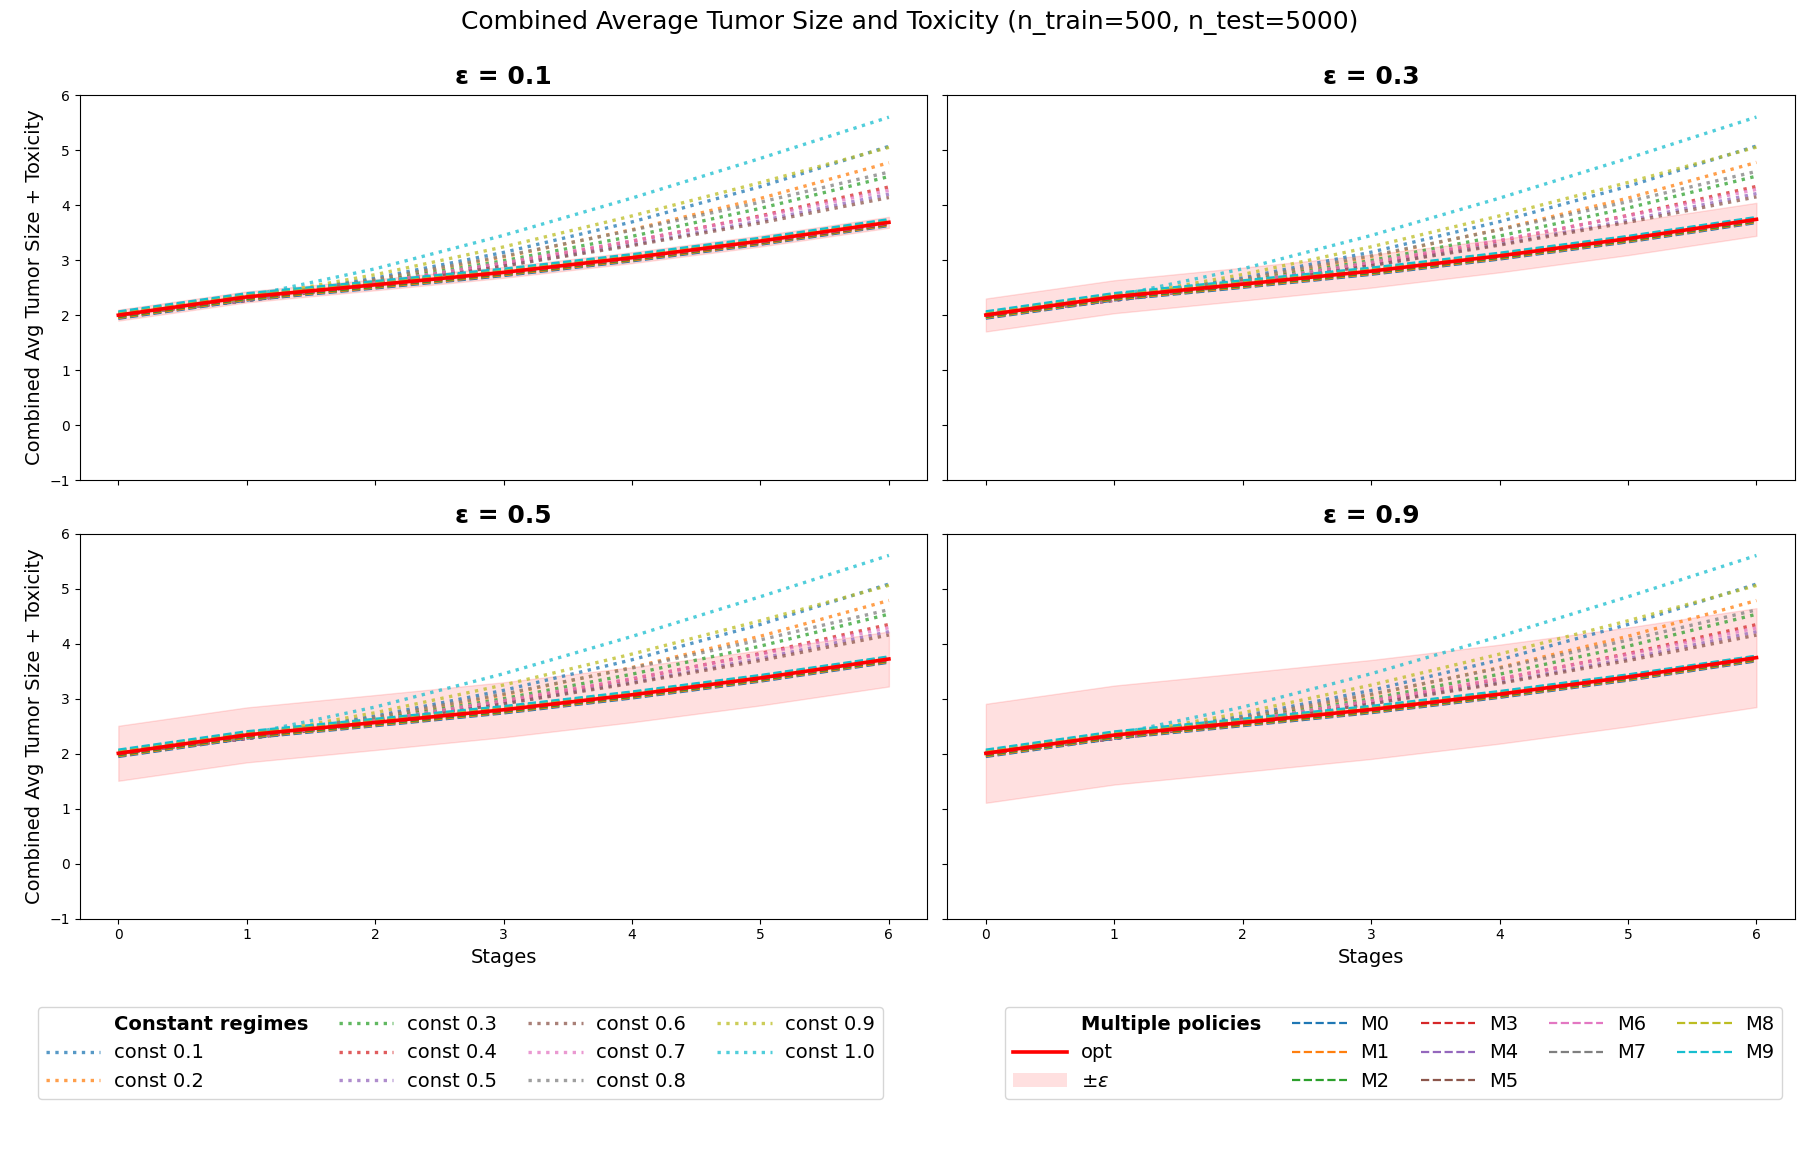

In [8]:
# ==========================================================
# PLOT
# ==========================================================

maxK = max(K_by_eps.values())

m_cmap = plt.get_cmap("tab10")
m_colors = {m: m_cmap(m % 10) for m in range(maxK)}

const_cmap = plt.get_cmap("tab10")
const_color_map = {
    d: const_cmap(i % 10)
    for i, d in enumerate(possibles_treatments)
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for idx, eps in enumerate(eps_list):
    ax = axes[idx]

    K_eps = K_by_eps[eps]
    mean_const = mean_const_by_eps[eps]
    opt_values = opt_values_by_eps[eps]
    mean_M = mean_M_by_eps[eps]

    # ---- constant dosage: dotted + thicker
    for d in possibles_treatments:
        ax.plot(
            time_grid,
            mean_const[d],
            linestyle=":",
            linewidth=2.4,
            alpha=0.75,
            color=const_color_map[d],
            zorder=2
        )

    # ---- classical optimal policy
    ax.plot(
        time_grid,
        opt_values,
        color="red",
        linestyle="-",
        linewidth=2.6,
        zorder=5
    )

    ax.fill_between(
        time_grid,
        opt_values - eps,
        opt_values + eps,
        color="red",
        alpha=0.12,
        zorder=1
    )

    # ---- near-equivalent policies: dashed
    eps_display = 0.015

    for m in range(K_eps):
        values = mean_M[f"M{m}"]
        delta = (m - (K_eps - 1) / 2) * eps_display

        ax.plot(
            time_grid,
            values + delta,
            linestyle="--",
            linewidth=1.6,
            color=m_colors[m],
            zorder=4
        )

    ax.set_ylim([-1, 6])
    ax.set_title(f"ε = {eps}", fontsize=18, fontweight="bold", pad=8)

    if idx in (2, 3):
        ax.set_xlabel("Stages", fontsize=14)

    if idx in (0, 2):
        ax.set_ylabel("Combined Avg Tumor Size + Toxicity", fontsize=14)

fig.suptitle(
    f"Combined Average Tumor Size and Toxicity "
    f"(n_train={N_train}, n_test={N_traj})",
    fontsize=18,
    y=0.95
)

plt.tight_layout(rect=[0, 0.14, 1, 0.95])

# ----------------------------------------------------------
# Legend band
# ----------------------------------------------------------
legend_ax = fig.add_axes([0.00, 0.00, 1.00, 0.13])
legend_ax.axis("off")

h_title_const = Line2D([], [], linestyle="None", label="Constant regimes")
h_title_model = Line2D([], [], linestyle="None", label="Multiple policies")

const_handles = [
    Line2D(
        [],
        [],
        linestyle=":",
        linewidth=2.4,
        alpha=0.75,
        color=const_color_map[d],
        label=f"const {d:.1f}"
    )
    for d in possibles_treatments
]

h_opt = Line2D(
    [],
    [],
    color="red",
    linestyle="-",
    linewidth=2.6,
    label="opt"
)

h_rib = Patch(
    facecolor="red",
    alpha=0.12,
    label=r"$\pm \epsilon$"
)

M_handles = [
    Line2D(
        [],
        [],
        linestyle="--",
        linewidth=1.6,
        color=m_colors[m],
        label=f"M{m}"
    )
    for m in range(maxK)
]

leg_left = legend_ax.legend(
    [h_title_const] + const_handles,
    ["Constant regimes"] + [h.get_label() for h in const_handles],
    ncol=4,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    fontsize=14,
    frameon=True,
    handlelength=2.8,
    columnspacing=1.6,
    handletextpad=0.7
)

for t in leg_left.get_texts():
    if t.get_text() == "Constant regimes":
        t.set_weight("bold")

legend_ax.add_artist(leg_left)

leg_right = legend_ax.legend(
    [h_title_model, h_opt, h_rib] + M_handles,
    ["Multiple policies", "opt", r"$\pm \epsilon$"] + [h.get_label() for h in M_handles],
    ncol=5,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.98),
    fontsize=14,
    frameon=True,
    handlelength=2.8,
    columnspacing=1.6,
    handletextpad=0.7
)

for t in leg_right.get_texts():
    if t.get_text() == "Multiple policies":
        t.set_weight("bold")

# ----------------------------------------------------------
# Save + show
# ----------------------------------------------------------
outname = (
    f"results/combined_average_tumor_size_and_toxicity_"
    f"epsilon_grid_nTrain{N_train}_nTest{N_traj}.png"
)

os.makedirs("results", exist_ok=True)
fig.savefig(outname, dpi=300, bbox_inches="tight")

plt.show()